In [2]:
%load_ext autoreload
%autoreload 2

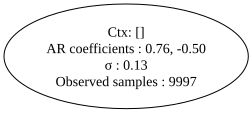

In [3]:
## We generate a standard AR model and try to fit a LiveARTree on it
import numpy as np
from ctw.models import LiveARTree, Quantizer
from ctw.tree import view_tree, view_tree_debug
from ctw.series import AR

# Parameters
np.random.seed(0)
order = 2
coefficients = [0.75, -0.5]
noise_std = 0.1
n_samples = 500
quantization_levels = 16
max_depth = 3

# Generate synthetic AR time series data
ar_model = AR(order, coefficients, noise_std, n_sample=10000)
data = [x for x in ar_model]

# Initialize quantizer
data_min, data_max = min(data), max(data)
thresholds = np.linspace(data_min, data_max, quantization_levels)
quantizer = Quantizer(thresholds)

# Initialize and fit LiveARTree model
live_ar_tree = LiveARTree(order=order, max_depth=max_depth, quantizer=quantizer, beta=0.5)
for x in data :
    live_ar_tree.observe(x)

# Visualize the resulting tree
view_tree(live_ar_tree.tree)


Comment : The tree is as expected and captures the right AR model. However one must be cautious because it can overfit when we add too much samples, it will create new levels of nodes. 

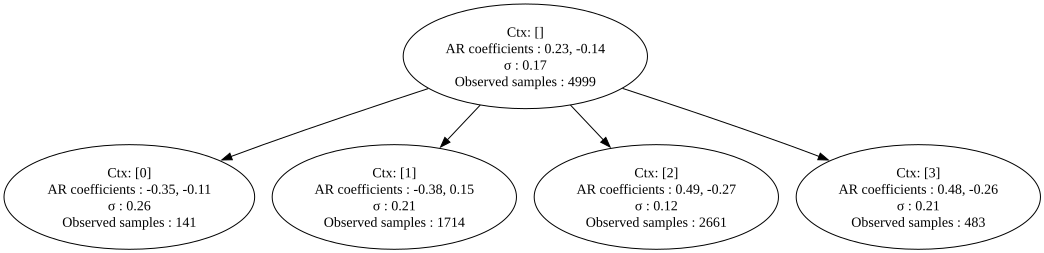

In [4]:
## Create a custom dual AR model and fit a LiveARTree on it (the value depends on the value 1 step back)
from ctw.tree import Tree, TreeNode, view_tree
import numpy as np
from matplotlib import pyplot as plt
from ctw.models import Quantizer

## Parameters
positive_ar_coeff = [0.5, -0.3]
positive_var = 0.1

negative_ar_coeff = [-0.4, 0.2]
negative_var = 0.2

def generate_dual_ar(init_seq = [0.0, 0.0], n_samples=1000) :
    x = init_seq[:]
    for i in range(n_samples) :
        if x[-1] > 0 :
            x.append(positive_ar_coeff[0]*x[-1] + positive_ar_coeff[1]*x[-2] + np.random.normal(0, positive_var))
        else :
            x.append(negative_ar_coeff[0]*x[-1] + negative_ar_coeff[1]*x[-2] + np.random.normal(0, negative_var))
    return x

data = generate_dual_ar(n_samples=5000)
thresholds = [-0.25, 0.0, 0.25, 0.5]
quantizer = Quantizer(thresholds)

live_ar_tree = LiveARTree(order=2, max_depth=3, quantizer=quantizer, beta=0.9)
for x in data :
    live_ar_tree.observe(x)

view_tree(live_ar_tree.tree)

The tree gets deeper when we complexify the model. Here we theoretically need only the last letter as context and the tree captures that correctly. Indeed even though we allowed for a max depth of 3, the tree prunes at the second level. Furthermore, the predicted coefficients and variance are quite close to the real ones.

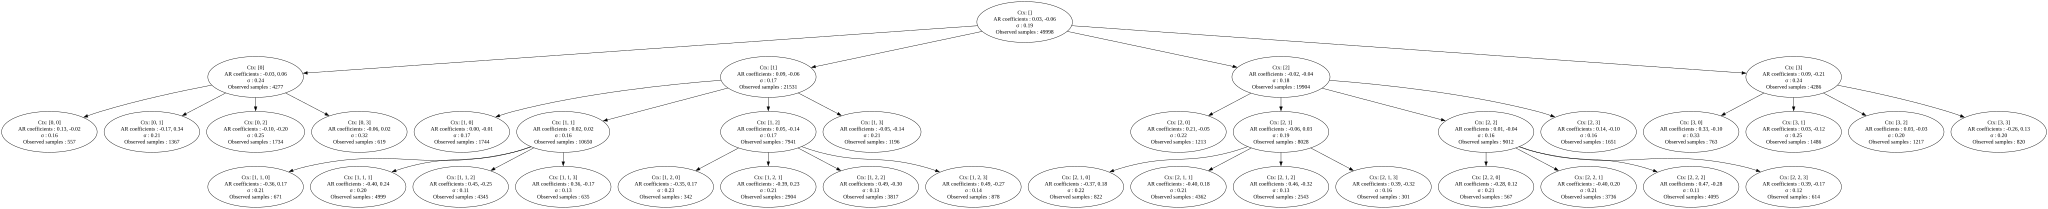

In [55]:
## This time , the AR model depends on the value 3 steps back
from ctw.tree import Tree, TreeNode, view_tree
import numpy as np
from matplotlib import pyplot as plt
from ctw.models import Quantizer

## Parameters
positive_ar_coeff = [0.5, -0.3]
positive_var = 0.1

negative_ar_coeff = [-0.4, 0.2]
negative_var = 0.2

def generate_dual_ar(init_seq = [0.0, 0.0, 0.0], n_samples=1000) :
    x = init_seq[:]
    for i in range(n_samples) :
        if x[-3] > 0 :
            x.append(positive_ar_coeff[0]*x[-1] + positive_ar_coeff[1]*x[-2] + np.random.normal(0, positive_var))
        else :
            x.append(negative_ar_coeff[0]*x[-1] + negative_ar_coeff[1]*x[-2] + np.random.normal(0, negative_var))
    return x

data = generate_dual_ar(n_samples=50000)
thresholds = [-0.25, 0.0, 0.25, 0.5]
quantizer = Quantizer(thresholds)

live_ar_tree = LiveARTree(order=2, max_depth=5, quantizer=quantizer, beta=0.5)
for x in data :
    live_ar_tree.observe(x)

view_tree(live_ar_tree.tree)

Comment : Once again, the true model requires a context of length 3 and the tree prunes at the third level, even though it's allowed to go much deeper. We are thus satisfied of its ability to calibrate itself.

## Prediction (CCTW)

### First we try to predict a shallow AR of order 2

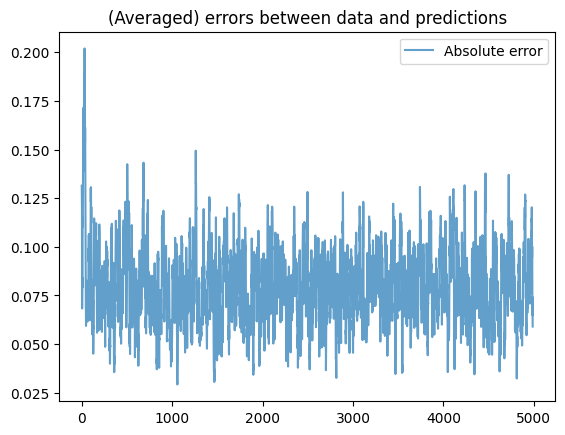

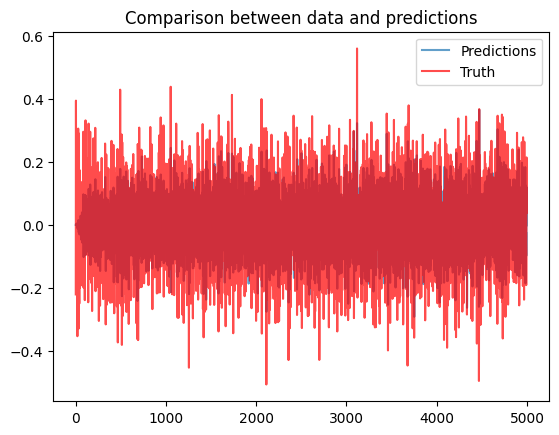

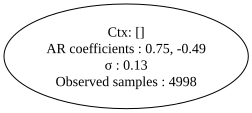

In [17]:
## We generate a standard AR model and try to fit a LiveARTree on it
import numpy as np
from ctw.models import LiveARTree, Quantizer
from ctw.tree import view_tree, view_tree_debug
from ctw.series import AR

# Parameters
np.random.seed(0)
order = 2
coefficients = [0.75, -0.5]
init_history = [1, 1]
noise_std = 0.1
n_samples = 5000
quantization_levels = 16
max_depth = 2

# Generate synthetic AR time series data
ar_model = AR(order, coefficients, noise_std, n_sample=n_samples, init_history=init_history)
data = [x for x in ar_model]

# Initialize quantizer
data_min, data_max = min(data), max(data)
thresholds = np.linspace(data_min, data_max, quantization_levels)
quantizer = Quantizer(thresholds)

# Initialize and fit LiveARTree model
live_ar_tree = LiveARTree(order=order, max_depth=max_depth, quantizer=quantizer, beta=0.5)
for k in range(order) :
    live_ar_tree.observe(data[k])

# Draw error curve between predicted and actual values
predictions = []
actuals = []
for x_i in data[order:]:
    prediction = live_ar_tree.predict_cctw(live_ar_tree._x[-2:])
    predictions.append(prediction)
    actuals.append(x_i)
    live_ar_tree.observe(x_i)
    
errors = [abs((p - a)) for p, a in zip(predictions, actuals)]
window = 10  
error_avg = np.convolve(errors, np.ones(window)/window, mode='valid')
plt.plot(error_avg, label = "Absolute error", alpha = 0.7)
plt.legend()
plt.title("(Averaged) errors between data and predictions")

plt.figure()
plt.plot(predictions, label = "Predictions", alpha = 0.7)
plt.plot(actuals, label = "Truth", alpha = 0.7, color = "red")
plt.legend()
plt.title("Comparison between data and predictions")
plt.show()

view_tree(live_ar_tree.tree)


Comment : The predictions are perfect when $\sigma = 0$ after enough history is processed. It is also decent when $\sigma > 0$ as it captures most of the signal, of the course the noise itself can never be recovered so the errors at convergence is not zero.

### Now we try to predict with a more complex model, composed of 2 AR models depending on the sign of the previous data (depth = 1)

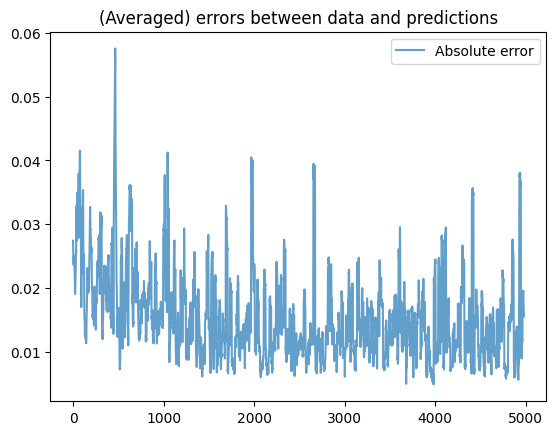

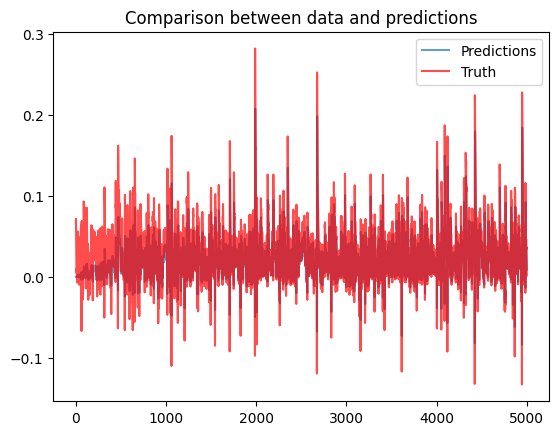

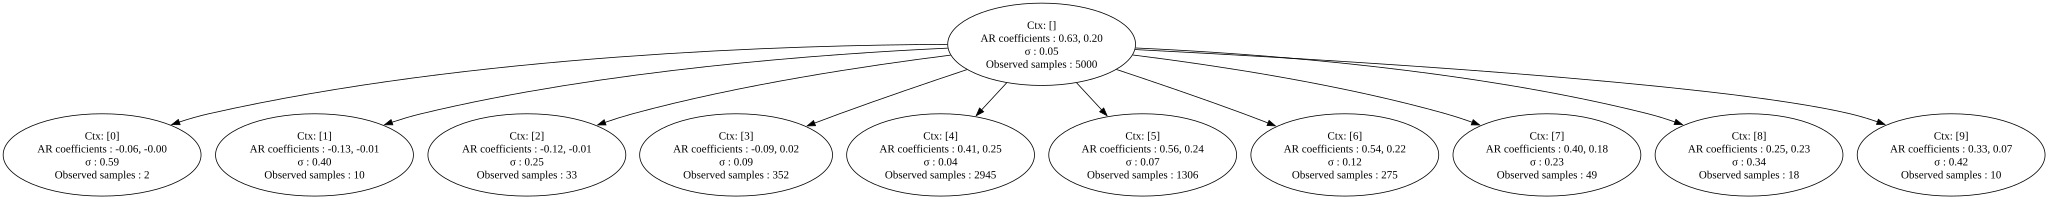

In [ ]:
## Create a custom dual AR model and fit a LiveARTree on it (the value depends on the value 1 step back)
from ctw.tree import Tree, TreeNode, view_tree
import numpy as np
from matplotlib import pyplot as plt
from ctw.models import Quantizer

## Parameters
positive_ar_coeff = [1, -0.1]
positive_var = 0.01

n_samples = 5000
order = 2
max_depth = 3

negative_ar_coeff = [-1.5, 0.5]
negative_var = 0.05

def generate_dual_ar(init_seq = [0, 0], n_samples=1000) :
    x = init_seq[:]
    for i in range(n_samples) :
        if x[-1] > 0 :
            x.append(positive_ar_coeff[0]*x[-1] + positive_ar_coeff[1]*x[-2] + np.random.normal(0, positive_var))
        else :
            x.append(negative_ar_coeff[0]*x[-1] + negative_ar_coeff[1]*x[-2] + np.random.normal(0, negative_var))
    return x

data = generate_dual_ar(n_samples=n_samples)
thresholds = np.linspace(-0.125, 0.25, 10)
quantizer = Quantizer(thresholds)

# Initialize and fit LiveARTree model
live_ar_tree = LiveARTree(order=order, max_depth=max_depth, quantizer=quantizer, beta=0.7)
for k in range(order) :
    live_ar_tree.observe(data[k])

# Draw error curve between predicted and actual values
predictions = []
actuals = []
for x_i in data[order:]:
    prediction = live_ar_tree.predict_cctw(live_ar_tree._x[-2:])
    predictions.append(prediction)
    actuals.append(x_i)
    live_ar_tree.observe(x_i)
    
errors = [abs((p - a)) for p, a in zip(predictions, actuals)]
window = 20  
error_avg = np.convolve(errors, np.ones(window)/window, mode='valid')
plt.plot(error_avg, label = "Absolute error", alpha = 0.7)
plt.legend()
plt.title("(Averaged) errors between data and predictions")

plt.figure()
plt.plot(predictions, label = "Predictions", alpha = 0.7)
plt.plot(actuals, label = "Truth", alpha = 0.7, color = "red")
plt.legend()
plt.title("Comparison between data and predictions")
plt.show()

view_tree(live_ar_tree.tree)


Comment : As before, the prediction completely fit the truth when $\sigma_1 = \sigma_2 = 0$. The model works nicely when the ratio noise signal is low enough (after seen a few samples). This behaviour is expected because if the noise is too high, performing a prediction for each sample can never make sense.